In [1]:
#r "nuget: ScottPlot, 5.0.*"

Installed Packages ScottPlot, 5.0.56

Loading extensions from `/home/artem/.nuget/packages/skiasharp/2.88.9/interactive-extensions/dotnet/SkiaSharp.DotNet.Interactive.dll`

Installed Packages skiasharp.nativeassets.linux.nodependencies, 2.88.9


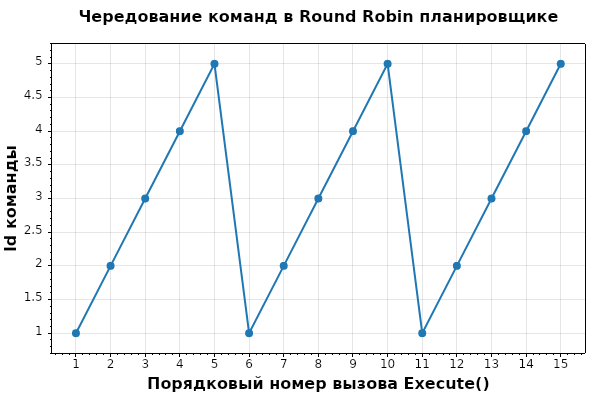

In [ ]:
#r "/home/artem/учёбаб/practice_2026/task17/bin/Debug/net10.0/task17.dll"

#r "nuget: SkiaSharp.NativeAssets.Linux.NoDependencies"

using System;
using System.Collections.Generic;
using System.IO;
using System.Linq;
using System.Threading;
using ScottPlot;
using task17;
using Microsoft.DotNet.Interactive.Formatting;

Formatter.Register(typeof(ScottPlot.Plot), (p, w) =>
    w.Write(((ScottPlot.Plot)p).GetPngHtml(600, 400)), HtmlFormatter.MimeType);

ScottPlot.Fonts.Default = "DejaVu Sans";

var executionOrder = new List<int>();

public class RecordingTestCommand : ICommand, ILongRunningCommand
{
    private readonly List<int> _log;
    private readonly int _id;
    private readonly int _maxCalls;
    private readonly CountdownEvent _completionSignal;
    private int _counter = 0;

    public RecordingTestCommand(List<int> log, int id, int maxCalls, CountdownEvent completionSignal)
    {
        _log = log;
        _id = id;
        _maxCalls = maxCalls;
        _completionSignal = completionSignal;
    }

    public bool IsCompleted => _counter >= _maxCalls;

    public void Execute()
    {
        _counter++;
        lock (_log) { _log.Add(_id); }
        if (IsCompleted)
            _completionSignal.Signal();
    }
}

var server = new ServerThread();
var completed = new CountdownEvent(5);

for (int id = 1; id <= 5; id++)
    server.Enqueue(new RecordingTestCommand(executionOrder, id, maxCalls: 3, completed));

completed.Wait();
server.Enqueue(new HardStop(server));
server.Join();

string filePath = "results.txt";
using (StreamWriter writer = new StreamWriter(filePath))
{
    writer.WriteLine("Порядок фактического выполнения (индекс вызова -> id команды):");
    for (int i = 0; i < executionOrder.Count; i++)
        writer.WriteLine($"{i + 1} -> команда {executionOrder[i]}");
    writer.WriteLine();
    writer.WriteLine($"Всего вызовов: {executionOrder.Count} (ожидается 5 команд * 3 вызова = 15)");
}

var plt = new ScottPlot.Plot();
var xs = Enumerable.Range(1, executionOrder.Count).Select(i => (double)i).ToArray();
var ys = executionOrder.Select(id => (double)id).ToArray();
var scatter = plt.Add.Scatter(xs, ys);
scatter.MarkerSize = 8;
scatter.LineWidth = 2;
plt.XLabel("Порядковый номер вызова Execute()");
plt.YLabel("Id команды");
plt.Title("Чередование команд в Round Robin планировщике");

plt.SavePng("plot.png", 800, 600);

plt

In [3]:
#r "/home/artem/учёбаб/practice_2026/task17/bin/Debug/net10.0/task17.dll"

using System;
using System.Threading;


var server = new ServerThread();
var completed = new CountdownEvent(5);

for (int id = 1; id <= 5; id++)
    server.Enqueue(new TestCommand(id, maxCalls: 3, completed));

completed.Wait();
server.Enqueue(new HardStop(server));
server.Join();

Console.WriteLine("Готово");

Поток 1 вызов 1
Поток 2 вызов 1
Поток 3 вызов 1
Поток 4 вызов 1
Поток 5 вызов 1
Поток 1 вызов 2
Поток 2 вызов 2
Поток 3 вызов 2
Поток 4 вызов 2
Поток 5 вызов 2
Поток 1 вызов 3
Поток 2 вызов 3
Поток 3 вызов 3
Поток 4 вызов 3
Поток 5 вызов 3
Готово
